In [1]:
import pandas as pd

# Load training dataset
df = pd.read_csv('/content/train.csv')

# Check dataset size
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# Dataset information
print("Dataset Information:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check unique digit labels
print("\nUnique Labels:")
print(sorted(df['label'].unique()))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB
None

Missing Values:
0

Duplicate Rows:
0

Unique Labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [3]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Show columns that have missing values
print("Columns with missing values:")
print(missing_values[missing_values > 0])

# Fill missing pixel values with 0
df.fillna(0, inplace=True)

# Check again
print("\nTotal Missing Values After Cleaning:")
print(df.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total Missing Values After Cleaning:
0


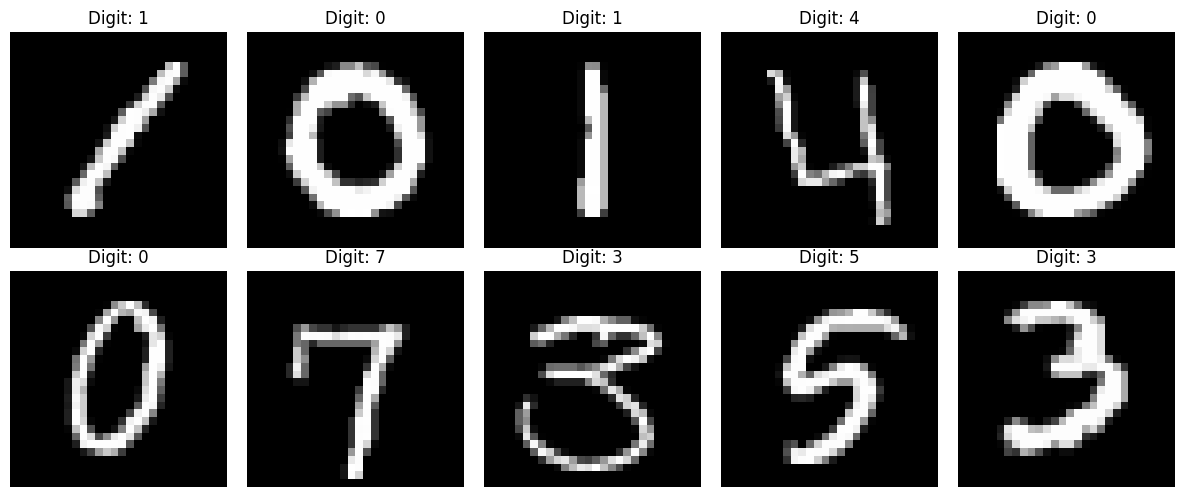

In [4]:
import matplotlib.pyplot as plt

# Separate labels and pixel data
X = df.drop('label', axis=1)
y = df['label']

# Display 10 sample images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X.iloc[i].values.reshape(28, 28), cmap='gray')
    plt.title(f"Digit: {y.iloc[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Number of images for each digit:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


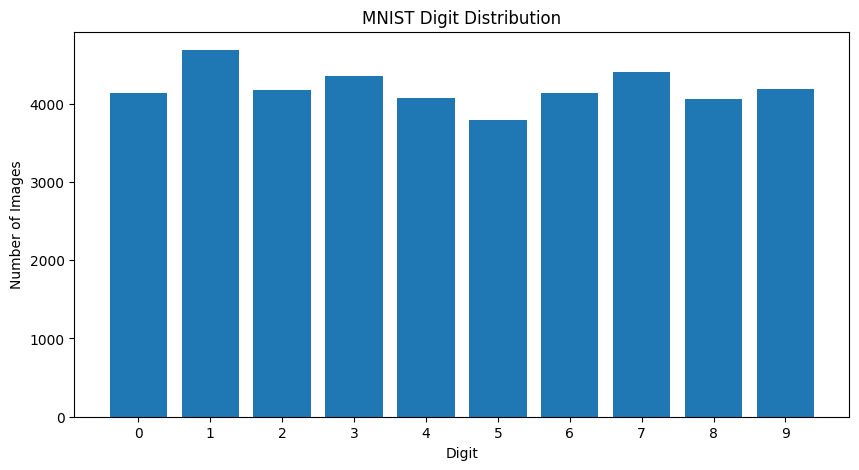

In [5]:
import matplotlib.pyplot as plt

# Count each digit
digit_counts = y.value_counts().sort_index()

# Display counts
print("Number of images for each digit:")
print(digit_counts)

# Plot digit distribution
plt.figure(figsize=(10, 5))
plt.bar(digit_counts.index, digit_counts.values)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Digit Distribution")
plt.xticks(range(10))

plt.show()

In [6]:
# Step 6: Normalize pixels and split dataset

# Import train_test_split
from sklearn.model_selection import train_test_split

# Normalize pixel values from 0-255 to 0-1
X = X / 255.0

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes of training and testing data
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

# Check normalized pixel values
print("\nMinimum pixel value:", X_train.min().min())
print("Maximum pixel value:", X_train.max().max())

Training data shape: (33600, 784)
Testing data shape: (8400, 784)
Training labels shape: (33600,)
Testing labels shape: (8400,)

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
# Step 7: Train Random Forest Classifier

# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using training data
model.fit(X_train, y_train)

# Print training completion message
print("Random Forest Model Training Completed!")

Random Forest Model Training Completed!


In [8]:
# Step 8: Evaluate Random Forest Model

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Predict digits using testing data
y_pred = model.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 96.39285714285715 %

Confusion Matrix:
[[808   0   2   2   1   4   8   0   2   0]
 [  0 929   2   2   0   0   1   1   2   0]
 [  3   1 803   7   5   0   4   7   3   2]
 [  3   1  15 816   1  17   1   5   7   4]
 [  0   1   2   0 789   0   4   1   0  17]
 [  1   0   0   9   2 721   8   1  11   6]
 [  3   2   0   0   0   3 816   0   3   0]
 [  0   4   6   2   2   1   0 851   4  10]
 [  1   3   6   5   0   8   4   0 773  13]
 [  6   1   2   8  11   3   0   9   7 791]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.96      0.96      0.96       835
           3       0.96      0.94      0.95       870
           4       0.97      0.97      0.97       814
           5       0.95      0.95      0.95       759
           6       0.96      0.99      0.98       827
           7       0.97      0.97      0.97       880
   

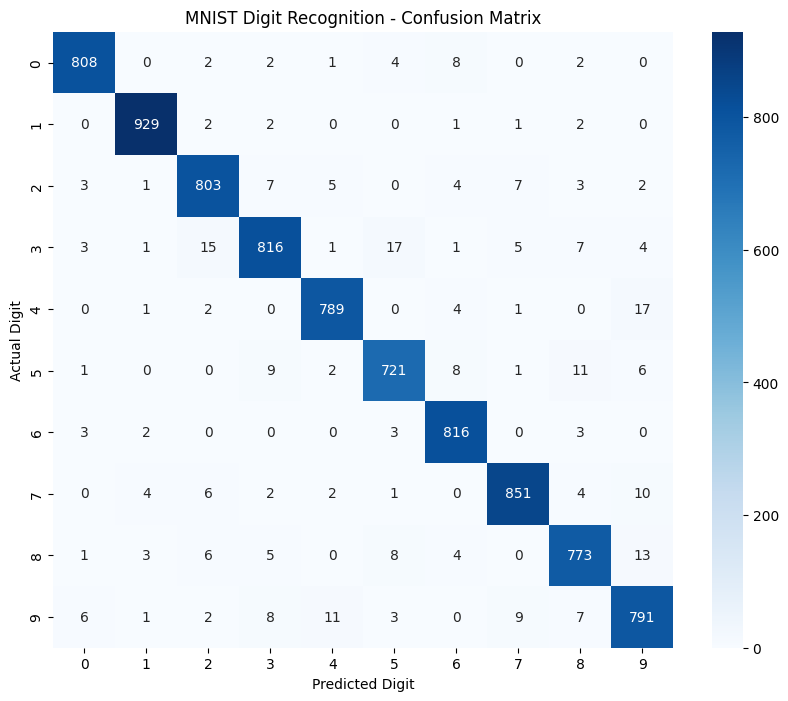

In [9]:
# Step 9: Visualize Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("MNIST Digit Recognition - Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

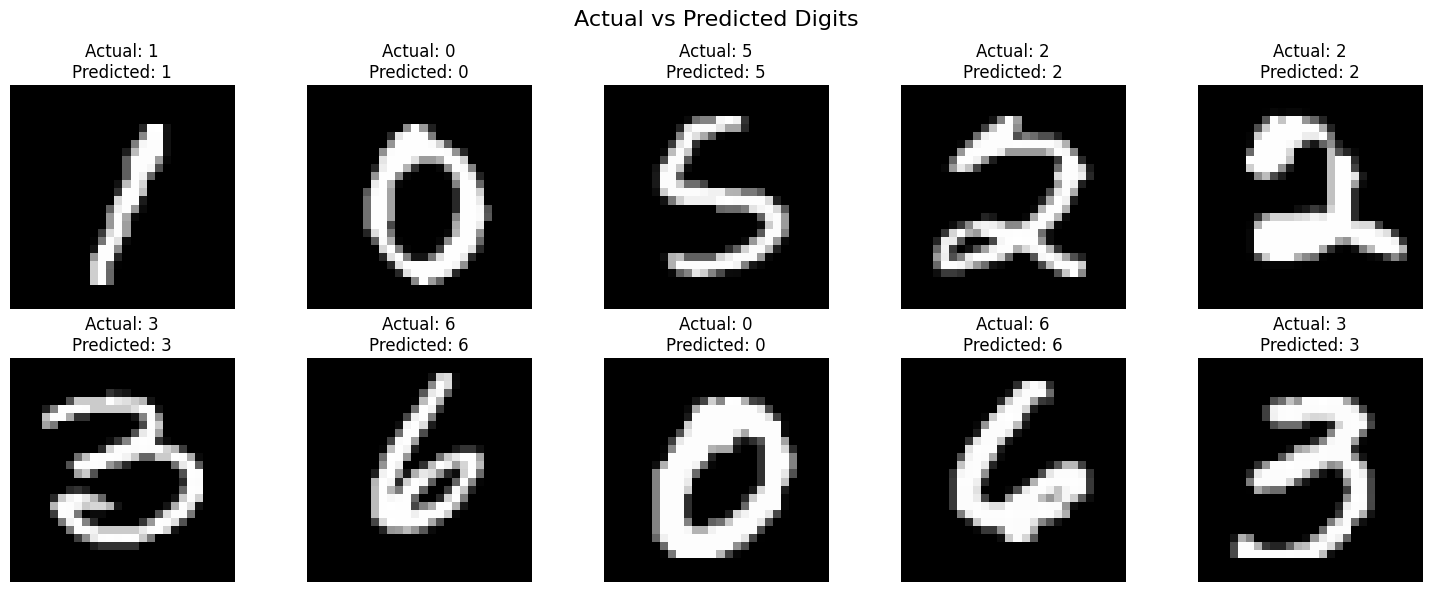

In [10]:
# Step 10: Visualize Actual vs Predicted Digits

import matplotlib.pyplot as plt
import numpy as np

# Select 10 random test images
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))

for i, index in enumerate(sample_indices):
    # Get image pixels
    image = X_test.iloc[index].values.reshape(28, 28)

    # Get actual and predicted labels
    actual = y_test.iloc[index]
    predicted = y_pred[index]

    # Display image
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.suptitle("Actual vs Predicted Digits", fontsize=16)
plt.tight_layout()
plt.show()

Total Incorrect Predictions: 303


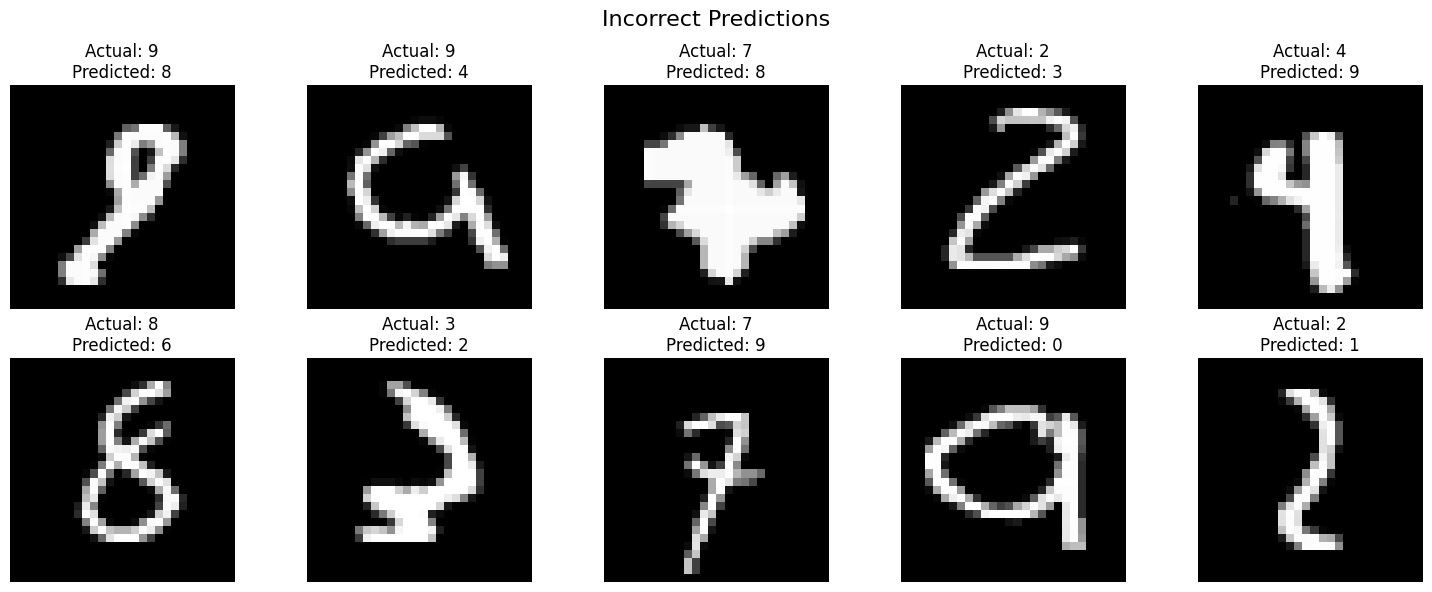

In [11]:
# Step 11: Visualize Incorrect Predictions

# Find the indexes where actual and predicted labels are different
incorrect_indices = np.where(y_test.values != y_pred)[0]

print("Total Incorrect Predictions:", len(incorrect_indices))

# Display first 10 incorrect predictions
plt.figure(figsize=(15, 6))

for i, index in enumerate(incorrect_indices[:10]):
    # Get image pixels
    image = X_test.iloc[index].values.reshape(28, 28)

    # Get actual and predicted labels
    actual = y_test.iloc[index]
    predicted = y_pred[index]

    # Display image
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.suptitle("Incorrect Predictions", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
# Step 12: Save the trained model

import joblib

# Save the trained Random Forest model
joblib.dump(model, "mnist_random_forest_model.pkl")

print("Model saved successfully!")
print("File name: mnist_random_forest_model.pkl")

Model saved successfully!
File name: mnist_random_forest_model.pkl


In [13]:
# Step 13: Verify the saved model

import joblib

# Load the saved model
loaded_model = joblib.load("mnist_random_forest_model.pkl")

# Make predictions using the loaded model
test_prediction = loaded_model.predict(X_test.iloc[:10])

print("Saved model loaded successfully!")
print("Predictions from saved model:", test_prediction)
print("Actual labels:", y_test.iloc[:10].values)

Saved model loaded successfully!
Predictions from saved model: [1 8 6 8 5 7 6 7 7 7]
Actual labels: [1 8 6 9 5 7 6 7 7 7]


In [14]:
# Step 14: Download the trained model

from google.colab import files

files.download("mnist_random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Step 15: Display Final Model Results

print("=" * 50)
print("       MNIST DIGIT RECOGNITION RESULTS")
print("=" * 50)

print(f"\nModel: Random Forest Classifier")
print(f"Dataset Size: {len(df)} images")
print(f"Training Images: {len(X_train)}")
print(f"Testing Images: {len(X_test)}")
print(f"Number of Classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nModel Performance:")
print(classification_report(y_test, y_pred))

print("=" * 50)

       MNIST DIGIT RECOGNITION RESULTS

Model: Random Forest Classifier
Dataset Size: 42000 images
Training Images: 33600
Testing Images: 8400
Number of Classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]

Model Accuracy: 96.39%

Model Performance:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.96      0.96      0.96       835
           3       0.96      0.94      0.95       870
           4       0.97      0.97      0.97       814
           5       0.95      0.95      0.95       759
           6       0.96      0.99      0.98       827
           7       0.97      0.97      0.97       880
           8       0.95      0.95      0.95       813
           9       0.94      0.94      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



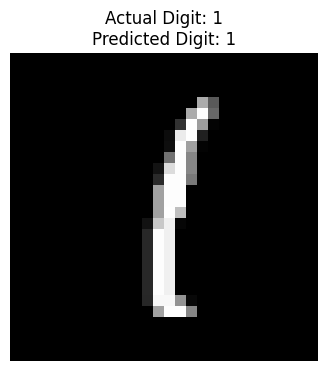

Actual Digit: 1
Predicted Digit: 1


In [19]:
# Step 16: Test a Single Digit Prediction

import matplotlib.pyplot as plt

# Select one test image
index = 0

# Get image and actual label
image = X_test.iloc[index].values.reshape(28, 28)
actual_digit = y_test.iloc[index]

# Predict the digit
predicted_digit = model.predict(X_test.iloc[[index]])[0]

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="grey")
plt.title(f"Actual Digit: {actual_digit}\nPredicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()

print("Actual Digit:", actual_digit)
print("Predicted Digit:", predicted_digit)

In [20]:
# Load test.csv
test_df = pd.read_csv("test.csv")

# Check shape
print("Test Dataset Shape:", test_df.shape)

# Show first 5 rows
display(test_df.head())

# Check missing values
print("\nMissing Values:")
print(test_df.isnull().sum().sum())

# Confirm pixel columns
pixel_columns = [col for col in test_df.columns if col.startswith("pixel")]

print("\nNumber of Pixel Columns:", len(pixel_columns))
print("First 5 Pixel Columns:", pixel_columns[:5])
print("Last 5 Pixel Columns:", pixel_columns[-5:])

Test Dataset Shape: (28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Missing Values:
0

Number of Pixel Columns: 784
First 5 Pixel Columns: ['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4']
Last 5 Pixel Columns: ['pixel779', 'pixel780', 'pixel781', 'pixel782', 'pixel783']


In [21]:
# Select only pixel columns from test data
X_test_final = test_df[pixel_columns].copy()

# Normalize pixel values
X_test_final = X_test_final / 255.0

# Check the result
print("Test Data Shape:", X_test_final.shape)
print("Minimum Pixel Value:", X_test_final.min().min())
print("Maximum Pixel Value:", X_test_final.max().max())

Test Data Shape: (28000, 784)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [22]:
# Predict digits using the already-trained Random Forest model
test_predictions = model.predict(X_test_final)

# Display first 20 predictions
print("First 20 Test Predictions:")
print(test_predictions[:20])

# Check total number of predictions
print("\nTotal Predictions:", len(test_predictions))

First 20 Test Predictions:
[2 0 9 9 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]

Total Predictions: 28000


In [23]:
# Create a DataFrame for test predictions
prediction_df = pd.DataFrame({
    "Prediction": test_predictions
})

# Show first 10 predictions
display(prediction_df.head(10))

# Check prediction distribution
print("\nPrediction Distribution:")
print(prediction_df["Prediction"].value_counts().sort_index())

,Prediction
0,2
1,0
2,9
3,9
4,3
5,7
6,0
7,3
8,0
9,3



Prediction Distribution:
Prediction
0    2787
1    3187
2    2850
3    2769
4    2748
5    2507
6    2776
7    2870
8    2719
9    2787
Name: count, dtype: int64


In [25]:
# Load sample submission file
sample_submission_df = pd.read_csv("sample_submission.csv")

# Check shape
print("Sample Submission Shape:", sample_submission_df.shape)

# Show first few rows
display(sample_submission_df.head())

# Show column names
print("\nSubmission Columns:")
print(sample_submission_df.columns.tolist())

Sample Submission Shape: (28000, 2)


,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0



Submission Columns:
['ImageId', 'Label']


In [26]:
# Create a copy of the sample submission format
submission_df = sample_submission_df.copy()

# Put our model predictions into the prediction column
submission_df["Label"] = test_predictions

# Check the submission
display(submission_df.head())

print("Submission Shape:", submission_df.shape)

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


Submission Shape: (28000, 2)


In [27]:
# Save the Kaggle submission file
submission_df.to_csv("mnist_submission.csv", index=False)

# Verify the saved file
print("Submission file saved successfully!")
print("File name: mnist_submission.csv")

# Display first 10 rows
display(submission_df.head(10))

Submission file saved successfully!
File name: mnist_submission.csv


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
5,6,7
6,7,0
7,8,3
8,9,0
9,10,3


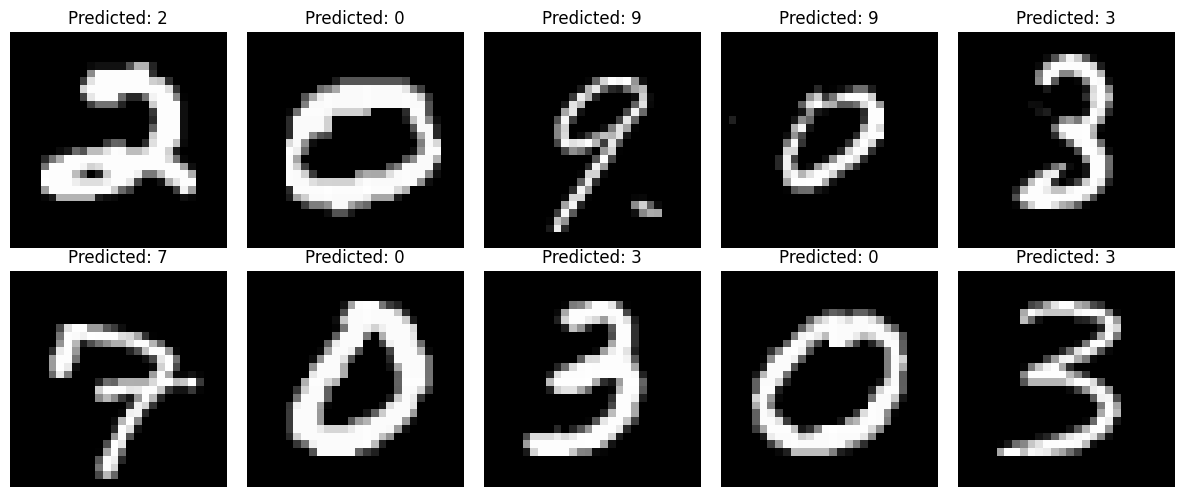

In [28]:
import matplotlib.pyplot as plt

# Display first 10 test images with predictions
plt.figure(figsize=(12, 5))

for i in range(10):
    image = X_test_final.iloc[i].values.reshape(28, 28)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Predicted: {test_predictions[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import os

# Check important project files
files_to_check = [
    "mnist_random_forest_model.pkl",
    "mnist_submission.csv"
]

for file_name in files_to_check:
    if os.path.exists(file_name):
        print(f"✓ {file_name} found")
    else:
        print(f"✗ {file_name} not found")

✓ mnist_random_forest_model.pkl found
✓ mnist_submission.csv found


In [30]:
from google.colab import files

files.download("mnist_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>